# Exploratory Data Analysis — FI-2010 Limit Order Book Dataset

This notebook performs EDA on the **FI-2010 benchmark dataset** for mid-price
movement prediction. It covers data loading, dataset inspection, descriptive
statistics, missing value analysis, feature distributions, and correlation analysis.

---
## 0. Imports & Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# ---------- plotting defaults ----------
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

dataset_root = "./BenchmarkDatasets"
N_FOLDS = 9

print(f"Dataset root: {dataset_root}")
assert os.path.isdir(dataset_root), f"Dataset directory not found: {dataset_root}"
print("Setup complete.")

Dataset root: ./BenchmarkDatasets
Setup complete.


---
## 1. Data Loading

We use the provided `load_fold` helper to load each of the 9 anchored folds,
concatenate them into pooled train/test arrays, and create a combined full
dataset for EDA.

In [2]:
# ── loader function (provided as-is) ────────────────────────────────────────

def load_fold(fold_idx, dataset_root, normalization='NoAuction_Zscore'):
    parts = normalization.split('_', 1)
    category, norm_name = parts
    norm_prefix_map = {'Zscore': '1', 'MinMax': '2', 'DecPre': '3'}
    prefix = norm_prefix_map[norm_name]
    file_norm_name_map = {'Zscore': 'ZScore', 'MinMax': 'MinMax', 'DecPre': 'DecPre'}
    file_norm_name = file_norm_name_map[norm_name]
    norm_dir = os.path.join(dataset_root, category, f"{prefix}.{category}_{norm_name}")
    train_dir = os.path.join(norm_dir, f"{category}_{norm_name}_Training")
    test_dir = os.path.join(norm_dir, f"{category}_{norm_name}_Testing")
    train_file = os.path.join(train_dir, f"Train_Dst_{category}_{file_norm_name}_CF_{fold_idx}.txt")
    test_file = os.path.join(test_dir, f"Test_Dst_{category}_{file_norm_name}_CF_{fold_idx}.txt")
    train_raw = np.loadtxt(train_file)
    test_raw = np.loadtxt(test_file)
    train_raw = train_raw.T
    test_raw = test_raw.T
    X_train = train_raw[:, :144].astype(np.float32)
    X_test = test_raw[:, :144].astype(np.float32)
    y_train_raw = train_raw[:, 148].astype(np.int64)
    y_test_raw = test_raw[:, 148].astype(np.int64)
    if 'Zscore' not in normalization:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
    y_train = y_train_raw - 1
    y_test = y_test_raw - 1
    classes = np.array([0, 1, 2])
    cw = compute_class_weight('balanced', classes=classes, y=y_train)
    class_weights = cw.astype(np.float32)
    return X_train, y_train, X_test, y_test, class_weights

In [3]:
# ── load all 9 folds ────────────────────────────────────────────────────────

fold_data = {}   # {fold_idx: (X_tr, y_tr, X_te, y_te, cw)}

X_train_list, y_train_list = [], []
X_test_list,  y_test_list  = [], []

for fold in range(1, N_FOLDS + 1):
    X_tr, y_tr, X_te, y_te, cw = load_fold(fold, dataset_root)
    fold_data[fold] = (X_tr, y_tr, X_te, y_te, cw)
    X_train_list.append(X_tr)
    y_train_list.append(y_tr)
    X_test_list.append(X_te)
    y_test_list.append(y_te)
    print(f"  Fold {fold}: train {X_tr.shape}, test {X_te.shape}")

# Concatenate across all folds
X_train = np.concatenate(X_train_list)
y_train = np.concatenate(y_train_list)
X_test  = np.concatenate(X_test_list)
y_test  = np.concatenate(y_test_list)

# Combined full dataset (train + test) for EDA
X_full = np.concatenate([X_train, X_test])
y_full = np.concatenate([y_train, y_test])

print(f"\nPooled shapes:")
print(f"  X_train {X_train.shape},  y_train {y_train.shape}")
print(f"  X_test  {X_test.shape},   y_test  {y_test.shape}")
print(f"  X_full  {X_full.shape},   y_full  {y_full.shape}")

  Fold 1: train (39512, 144), test (38397, 144)
  Fold 2: train (77909, 144), test (28535, 144)
  Fold 3: train (106444, 144), test (37023, 144)
  Fold 4: train (143467, 144), test (34785, 144)
  Fold 5: train (178252, 144), test (39152, 144)
  Fold 6: train (217404, 144), test (37346, 144)
  Fold 7: train (254750, 144), test (55478, 144)
  Fold 8: train (310228, 144), test (52172, 144)
  Fold 9: train (362400, 144), test (31937, 144)

Pooled shapes:
  X_train (1690366, 144),  y_train (1690366,)
  X_test  (354825, 144),   y_test  (354825,)
  X_full  (2045191, 144),   y_full  (2045191,)


---
## 2. Dataset Inspection

Quick look at the shape, data types, and first/last rows of the full dataset.

### Understanding the Data

Before inspecting the raw numbers, it is important to understand what each
**row** and **column** represents — otherwise the output is just a wall of
floats.

#### Rows (samples)

Each row is a **single time-step snapshot** of the limit order book (LOB).
It captures the full state of the order book at one discrete moment in time.
The rows are sequential — row 0 occurs before row 1, and so on — preserving
the temporal ordering of the market.

#### Columns (F0 – F143) — the 144 features

The 144 features are organised into four functional groups:

| Feature Range | Count | Description |
|:---|:---:|:---|
| **F0 – F39** | 40 | **Raw LOB snapshot** — 10 price levels × 4 values each: *(ask price, ask volume, bid price, bid volume)*. F0 = best ask price, F1 = best ask volume, F2 = best bid price, F3 = best bid volume; F4–F7 for level 2, and so on up to level 10. |
| **F40 – F53** | 14 | **Time-insensitive features** — derived quantities computed from the current snapshot only: bid-ask spread, mid-price, price & volume differences across levels, mean prices & volumes, accumulated differences. |
| **F54 – F93** | 40 | **Time-sensitive features (set 1)** — statistics computed over rolling time windows: price & volume derivatives, intensity of price changes, etc. |
| **F94 – F143** | 50 | **Time-sensitive features (set 2)** — additional rolling-window features: relative intensity, return volatility, trade-sign correlations, etc. |

#### Labels (y)

The label vector (stored separately as `y_train` / `y_test` / `y_full`)
encodes the **mid-price movement direction** at prediction horizon *k* = 10
time steps into the future:

| Label | Meaning |
|:---:|:---|
| 0 | **Down** — mid-price decreased |
| 1 | **Stationary** — mid-price unchanged |
| 2 | **Up** — mid-price increased |

> **Note:** All feature values are **Z-score normalised**, so they are centred
> around zero with approximately unit variance. The numbers you see below are
> *not* raw prices or volumes — they are standardised scores.

In [4]:
# Build a DataFrame for convenient inspection
feature_names = [f"F{i}" for i in range(144)]
df_full = pd.DataFrame(X_full, columns=feature_names)

print(f"Shape          : {df_full.shape}")
print(f"Data types     : {df_full.dtypes.unique()}")
print(f"Memory usage   : {df_full.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print()

Shape          : (2045191, 144)
Data types     : [dtype('float32')]
Memory usage   : 1178.0 MB



In [5]:
# ── head() ──────────────────────────────────────────────────────────────────
print("First 5 rows:")
display(df_full.head())

First 5 rows:


,F0,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F134,F135,F136,F137,F138,F139,F140,F141,F142,F143
0,0.408275,-0.509405,0.403577,-0.479331,0.409877,-0.663252,0.402914,-0.37744,0.409493,-0.787505,...,-1.597065,0.0,0.0,0.0,-0.143968,-0.879782,-0.887778,0.0,0.0,0.0
1,0.408275,-0.604272,0.403577,-0.479331,0.410898,-0.683978,0.402914,-0.37744,0.410513,-0.799630,...,-1.597065,0.0,0.0,0.0,-0.143968,0.381572,0.370280,0.0,0.0,0.0
2,0.407254,-0.663731,0.403577,-0.479331,0.406815,-0.663252,0.402914,-0.37744,0.407452,-0.695636,...,-1.597065,0.0,0.0,0.0,-0.143968,-0.862017,-0.870059,0.0,0.0,0.0
3,0.407254,-0.530115,0.403577,-0.479331,0.408857,-0.238357,0.402914,-0.37744,0.409493,-0.467596,...,0.626132,0.0,0.0,0.0,-0.143968,0.383221,0.371925,0.0,0.0,0.0
4,0.407254,-0.530115,0.403577,-0.479331,0.408857,-0.238357,0.402914,-0.37744,0.409493,-0.467596,...,0.626132,0.0,0.0,0.0,-0.143968,-0.479532,-0.488573,0.0,0.0,0.0


In [6]:
# ── tail() ──────────────────────────────────────────────────────────────────
print("Last 5 rows:")
display(df_full.tail())

Last 5 rows:


,F0,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F134,F135,F136,F137,F138,F139,F140,F141,F142,F143
2045186,1.462738,-0.030648,1.467926,-0.197623,1.462118,-0.401187,1.465580,-0.569871,1.461516,-0.0048,...,0.612438,0.0,0.0,0.0,-0.139927,1.624460,1.610326,0.0,0.0,0.0
2045187,1.462738,-0.030648,1.467926,-0.197623,1.462118,-0.401187,1.465580,-0.623560,1.461516,-0.0048,...,0.612438,0.0,0.0,0.0,-0.139927,-0.824794,-0.833181,0.0,0.0,0.0
2045188,1.462738,-0.030648,1.467926,-0.197623,1.462118,-0.401187,1.465580,-0.677249,1.461516,-0.0048,...,-1.632813,0.0,0.0,0.0,-0.139927,-0.494134,-0.503298,0.0,0.0,0.0
2045189,1.462738,-0.030648,1.467926,-0.197623,1.462118,-0.401187,1.466562,-0.737917,1.461516,-0.0048,...,-1.632813,0.0,0.0,0.0,-0.139927,0.460724,0.449320,0.0,0.0,0.0
2045190,1.462738,-0.030648,1.467926,-0.197623,1.462118,-0.401187,1.465580,-0.677249,1.461516,-0.0048,...,0.612438,0.0,0.0,0.0,-0.139927,-0.571369,-0.580351,0.0,0.0,0.0


---
## 3. Descriptive Statistics

Compute standard summary statistics across all 144 features: mean, median, mode,
standard deviation, variance, min, max, quartiles (Q1, Q2, Q3), skewness, and kurtosis.

In [7]:
# ── Core descriptive statistics ─────────────────────────────────────────────

desc = df_full.describe().T
desc = desc.rename(columns={
    "count": "Count", "mean": "Mean", "std": "Std",
    "min": "Min", "25%": "Q1", "50%": "Median (Q2)", "75%": "Q3", "max": "Max"
})

# Add median explicitly, mode, variance, skewness, kurtosis
desc["Variance"] = df_full.var()
desc["Mode"] = df_full.mode().iloc[0]
desc["Skewness"] = df_full.skew()
desc["Kurtosis"] = df_full.kurtosis()

# Reorder columns for clarity
desc = desc[["Count", "Mean", "Median (Q2)", "Mode", "Std", "Variance",
             "Min", "Q1", "Q3", "Max", "Skewness", "Kurtosis"]]

display(desc.round(4))

,Count,Mean,Median (Q2),Mode,Std,Variance,Min,Q1,Q3,Max,Skewness,Kurtosis
F0,2045191.0,0.0064,-0.5312,-0.9919,1.0063,1.0127,-1.0907,-0.9962,1.1700,1.4637,0.2386,-1.762900
F1,2045191.0,0.0124,-0.3795,-0.6696,1.0136,1.0274,-0.8279,-0.6236,0.2663,17.5579,2.9401,15.616200
F2,2045191.0,0.0064,-0.5303,-0.9799,1.0063,1.0127,-1.0897,-0.9967,1.1693,1.4689,0.2389,-1.762200
F3,2045191.0,-0.0062,-0.3738,-0.6329,0.9757,0.9520,-0.7608,-0.5748,0.2174,37.8162,6.0033,129.602997
F4,2045191.0,0.0063,-0.5314,-0.9919,1.0063,1.0127,-1.0907,-0.9961,1.1695,1.4631,0.2385,-1.763000
...,...,...,...,...,...,...,...,...,...,...,...,...
F139,2045191.0,-0.0071,-0.4606,-0.8293,0.9975,0.9950,-0.8920,-0.8011,0.4878,5.6187,1.4514,2.082700
F140,2045191.0,-0.0071,-0.4474,-0.8377,0.9975,0.9951,-0.9000,-0.8077,0.4820,5.5952,1.4337,2.023500
F141,2045191.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000000
F142,2045191.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000000


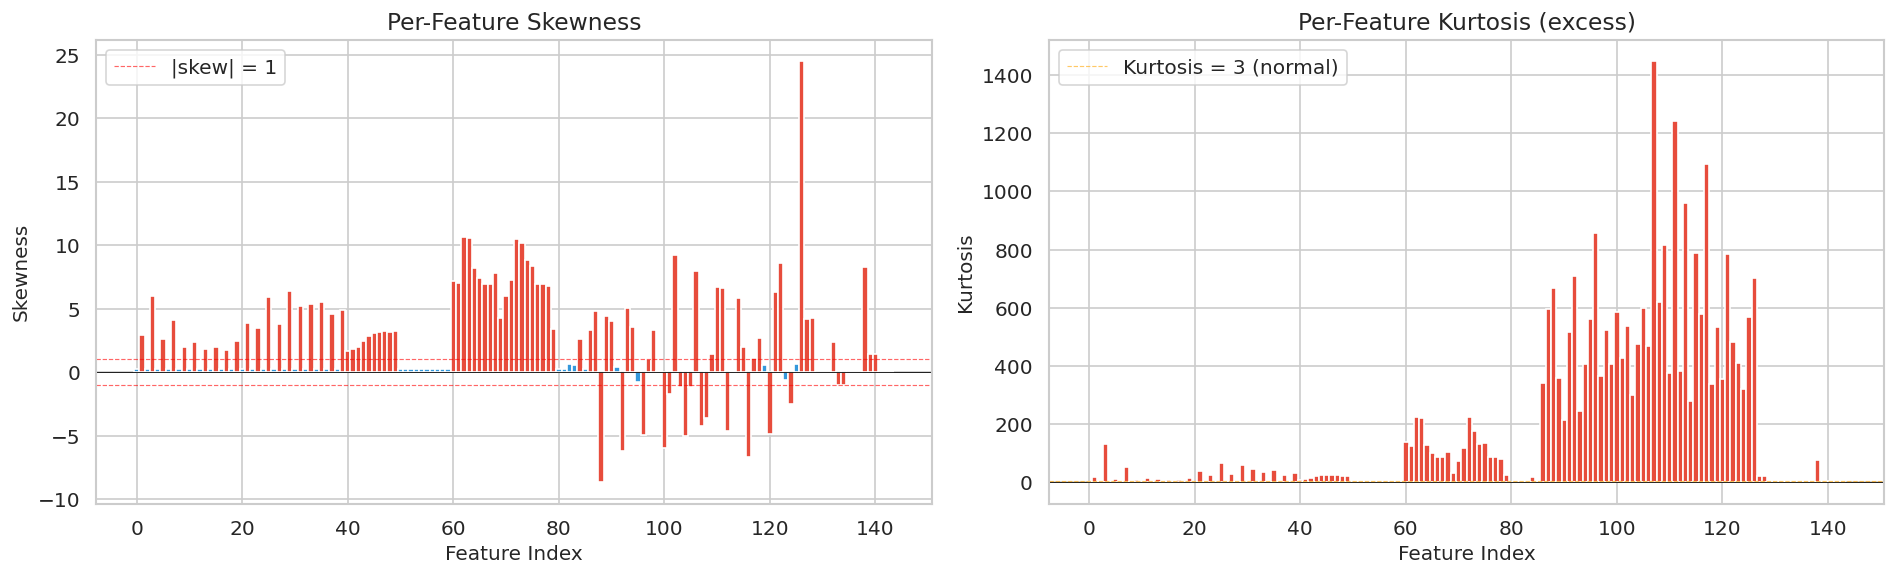

Features with |skewness| > 1: 93
Features with kurtosis  > 5 : 95


In [8]:
# ── Skewness bar chart ──────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

skew_vals = df_full.skew()
colors_skew = ["#e74c3c" if abs(v) > 1 else "#3498db" for v in skew_vals]
axes[0].bar(range(144), skew_vals, color=colors_skew, width=1.0)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].axhline(1, color="red", linewidth=0.7, linestyle="--", alpha=0.6, label="|skew| = 1")
axes[0].axhline(-1, color="red", linewidth=0.7, linestyle="--", alpha=0.6)
axes[0].set_title("Per-Feature Skewness")
axes[0].set_xlabel("Feature Index")
axes[0].set_ylabel("Skewness")
axes[0].legend()

# ── Kurtosis bar chart ─────────────────────────────────────────────────────
kurt_vals = df_full.kurtosis()
colors_kurt = ["#e74c3c" if v > 5 else "#2ecc71" for v in kurt_vals]
axes[1].bar(range(144), kurt_vals, color=colors_kurt, width=1.0)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].axhline(3, color="orange", linewidth=0.7, linestyle="--", alpha=0.6, label="Kurtosis = 3 (normal)")
axes[1].set_title("Per-Feature Kurtosis (excess)")
axes[1].set_xlabel("Feature Index")
axes[1].set_ylabel("Kurtosis")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Features with |skewness| > 1: {(skew_vals.abs() > 1).sum()}")
print(f"Features with kurtosis  > 5 : {(kurt_vals > 5).sum()}")

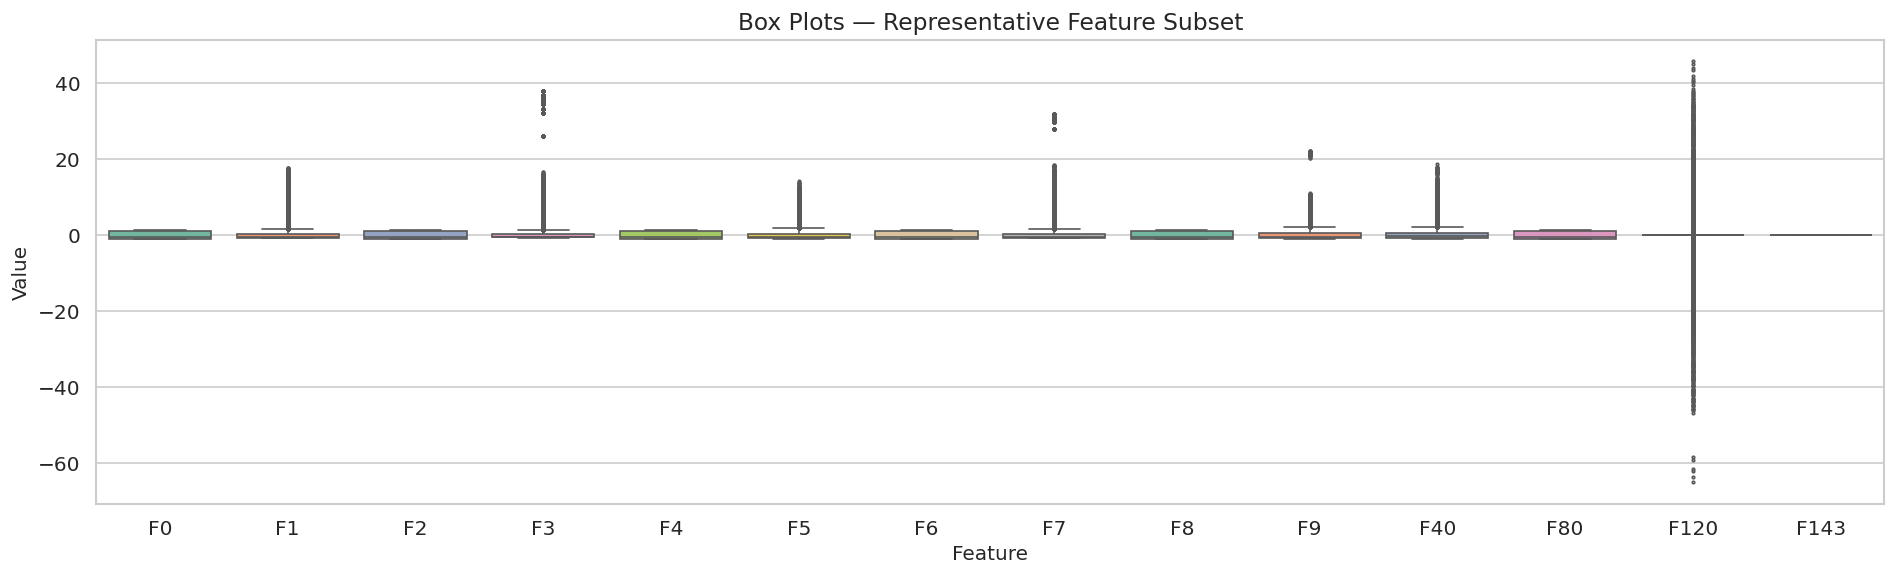

In [9]:
# ── Box plots for a representative subset of features ──────────────────────

subset_idx = list(range(10)) + [40, 80, 120, 143]
df_subset = pd.DataFrame(X_full[:, subset_idx], columns=[f"F{i}" for i in subset_idx])

fig, ax = plt.subplots(figsize=(16, 5))
sns.boxplot(data=df_subset, orient="v", palette="Set2", fliersize=1.5, ax=ax)
ax.set_title("Box Plots — Representative Feature Subset")
ax.set_xlabel("Feature")
ax.set_ylabel("Value")
plt.tight_layout()
plt.show()

---
## 4. Missing Values Analysis

Check for missing values (NaN / Inf) across the full dataset and report a
handling strategy.

In [10]:
# ── Check for NaN and Inf values ────────────────────────────────────────────

nan_per_feature = df_full.isna().sum()
total_nans = nan_per_feature.sum()
inf_count = np.isinf(X_full).sum()

print(f"Total NaN values : {total_nans}")
print(f"Total Inf values : {inf_count}")
print(f"Any NaN?         : {df_full.isna().any().any()}")
print(f"Any Inf?         : {np.isinf(X_full).any()}")
print()

if total_nans > 0:
    # Show features with missing values
    missing = nan_per_feature[nan_per_feature > 0].sort_values(ascending=False)
    print("Features with missing values:")
    display(missing.to_frame("Missing Count"))
    
    # Missing value percentage heatmap
    fig, ax = plt.subplots(figsize=(16, 2))
    missing_pct = (df_full.isna().sum() / len(df_full) * 100).values.reshape(1, -1)
    sns.heatmap(missing_pct, ax=ax, cmap="YlOrRd", cbar_kws={"label": "% Missing"},
                xticklabels=10, yticklabels=False)
    ax.set_xlabel("Feature Index")
    ax.set_title("Missing Value Percentage per Feature")
    plt.tight_layout()
    plt.show()
else:
    print("✓ No missing or infinite values detected.")
    print()
    print("Handling strategy: The FI-2010 dataset is fully pre-processed with")
    print("Z-score normalisation. No imputation or removal is required.")
    print("If NaNs or Infs were present, appropriate strategies would include:")
    print("  • Imputation (mean/median for numerical features)")
    print("  • Forward/backward fill for time-series context")
    print("  • Row removal if the fraction is negligible (< 1%)")

Total NaN values : 0
Total Inf values : 0
Any NaN?         : False
Any Inf?         : False

✓ No missing or infinite values detected.

Handling strategy: The FI-2010 dataset is fully pre-processed with
Z-score normalisation. No imputation or removal is required.
If NaNs or Infs were present, appropriate strategies would include:
  • Imputation (mean/median for numerical features)
  • Forward/backward fill for time-series context
  • Row removal if the fraction is negligible (< 1%)


---
## 5. Feature Distributions

Histograms for a representative subset of numerical features. We select the
first 12 features (F0–F11) plus a few from deeper in the feature vector
(F40, F80, F120) to cover different LOB levels and derived features.

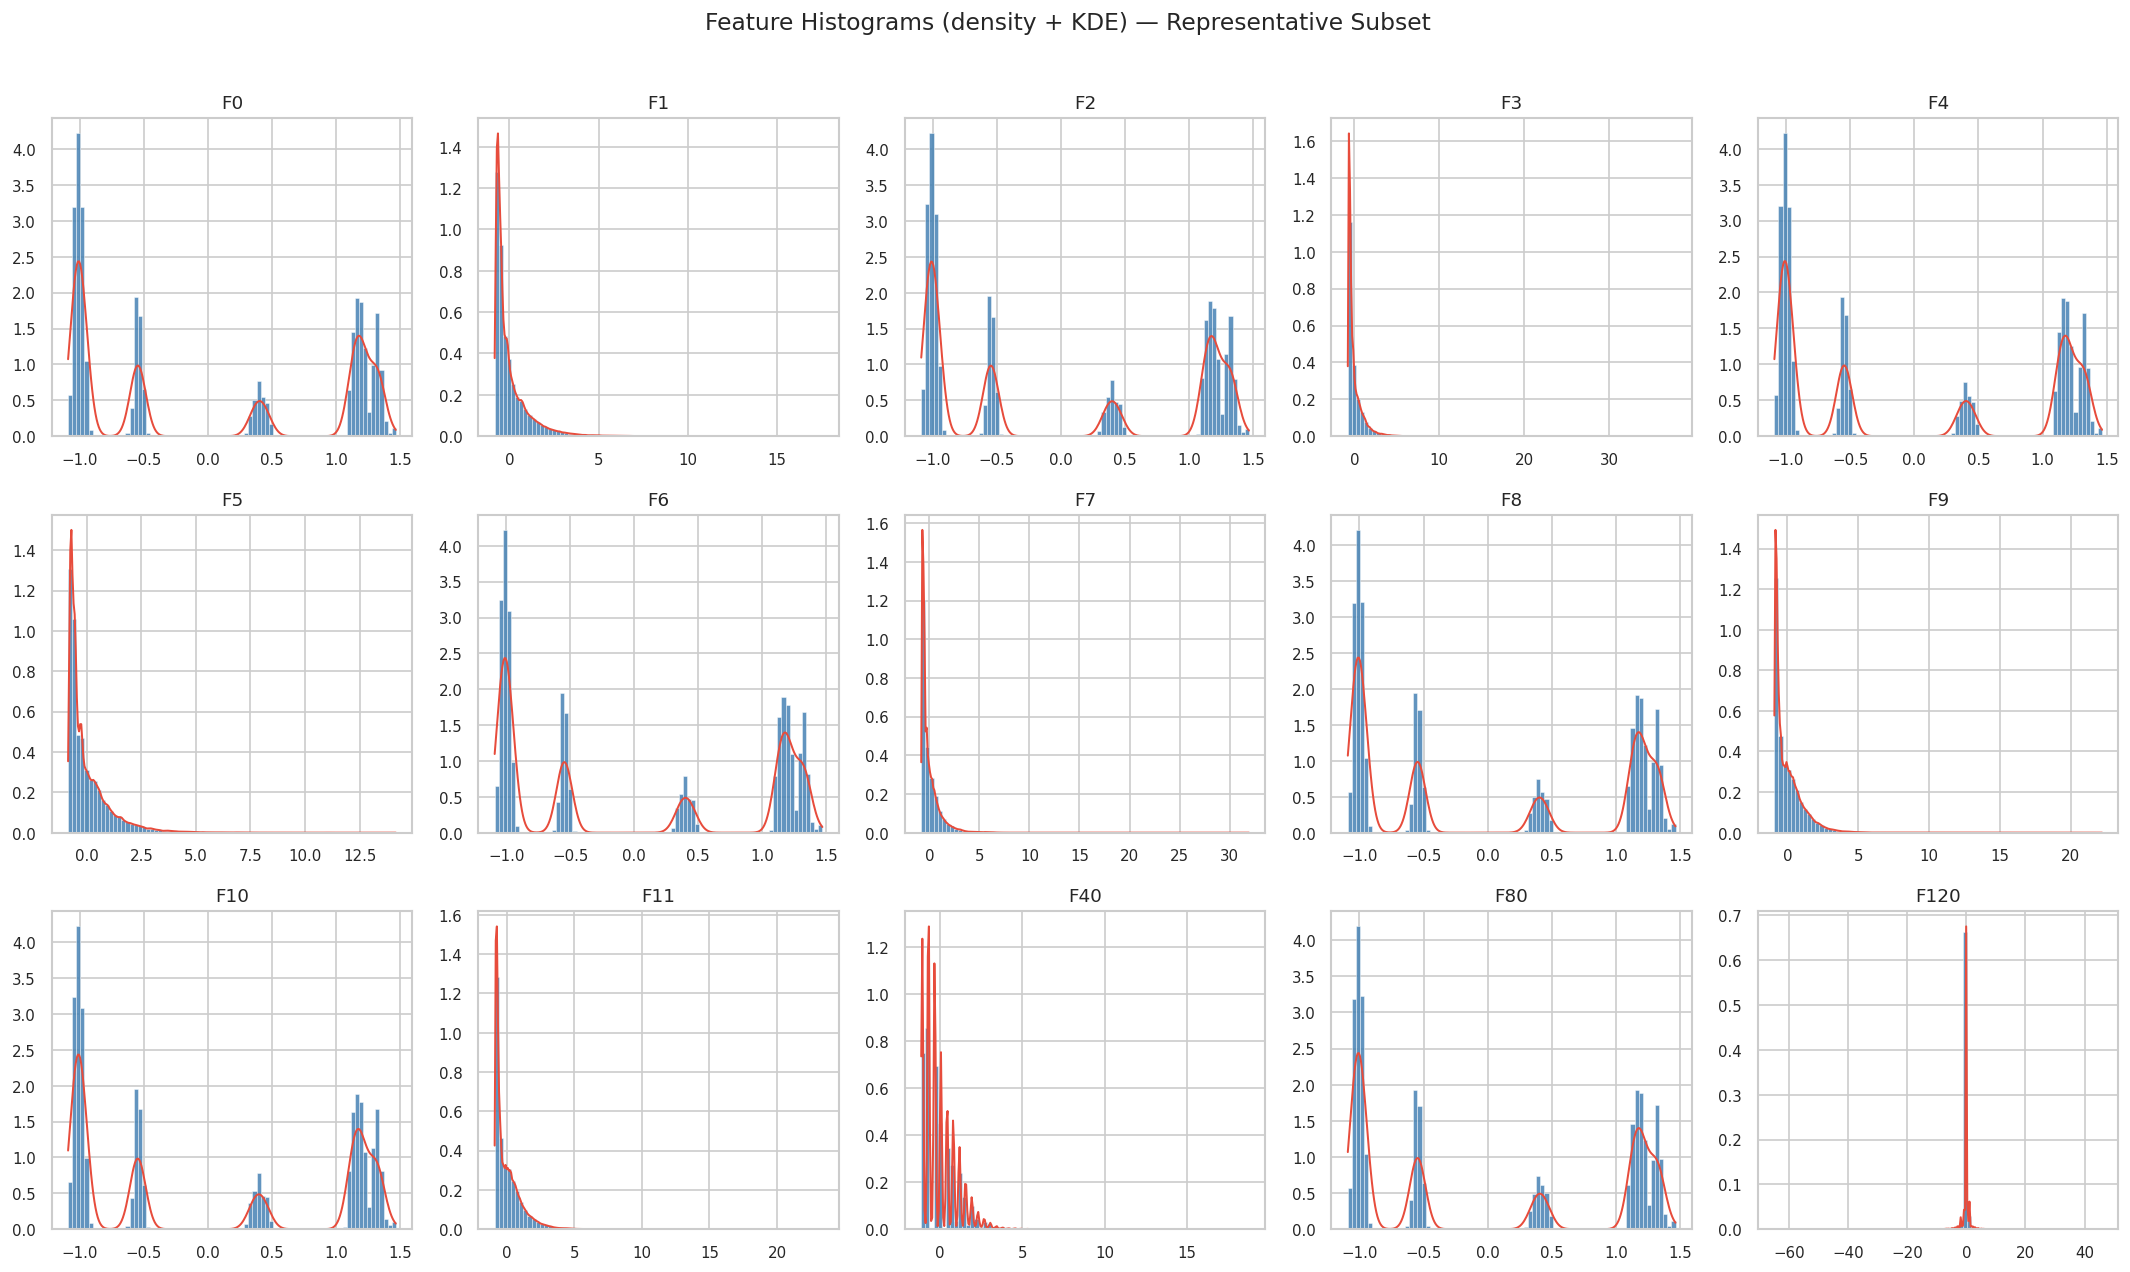

In [11]:
# ── Histograms for a representative subset ─────────────────────────────────

subset_idx = list(range(12)) + [40, 80, 120]
n_feats = len(subset_idx)
ncols = 5
nrows = int(np.ceil(n_feats / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.5 * nrows))
axes = axes.ravel()

for i, fidx in enumerate(subset_idx):
    ax = axes[i]
    data = X_full[:, fidx]
    ax.hist(data, bins=80, color="steelblue", edgecolor="white",
            linewidth=0.3, density=True, alpha=0.85)
    # Overlay a KDE for shape reference
    try:
        kde_x = np.linspace(data.min(), data.max(), 300)
        kde = stats.gaussian_kde(data)
        ax.plot(kde_x, kde(kde_x), color="#e74c3c", linewidth=1.2)
    except Exception:
        pass
    ax.set_title(f"F{fidx}", fontsize=11)
    ax.tick_params(labelsize=9)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Histograms (density + KDE) — Representative Subset",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Distribution Analysis

**Observations on the representative feature subset:**

- **Normality**: Most features deviate from a perfect normal distribution.
  The Z-score normalisation centres them around zero with unit variance, but
  many exhibit heavy tails or asymmetry.
- **Skewness**: Several features (especially volume-related ones) show positive
  skewness, indicating a long right tail. Price-level features tend to be more
  symmetric.
- **Multimodal behaviour**: Some features show bimodal or multimodal density
  peaks, which may reflect distinct market regimes (e.g., high vs. low
  volatility periods).
- **Outliers**: Heavy-tailed distributions suggest the presence of outliers,
  particularly in volume and spread-derived features. These are genuine market
  events rather than data errors.

---
## 6. Correlation Analysis

Full Pearson correlation matrix across all 144 features, visualised as a
heatmap. The 40-feature block boundaries (LOB depth levels 1–4) are marked.

In [12]:
# ── Full correlation matrix computation ─────────────────────────────────────
# Some features may have zero variance (constant columns), which causes
# division-by-zero warnings in np.corrcoef. We identify and exclude them.

feature_stds = X_full.std(axis=0)
zero_var_mask = feature_stds == 0
n_zero_var = zero_var_mask.sum()

if n_zero_var > 0:
    zero_var_features = np.where(zero_var_mask)[0]
    print(f"⚠ {n_zero_var} feature(s) with zero variance (constant): {zero_var_features.tolist()}")
    print("  These will be excluded from the correlation computation.\n")
else:
    print("All 144 features have non-zero variance.\n")

# Keep only features with non-zero variance
valid_mask = ~zero_var_mask
X_valid = X_full[:, valid_mask]
valid_indices = np.where(valid_mask)[0]
n_valid = valid_mask.sum()

corr_matrix = np.corrcoef(X_valid.T)  # (n_valid, n_valid)
# Replace any residual NaN with 0 (safety net)
corr_matrix = np.nan_to_num(corr_matrix, nan=0.0)

print(f"Correlation matrix shape: {corr_matrix.shape}")

# Summary statistics of off-diagonal correlations
upper_tri = corr_matrix[np.triu_indices(n_valid, k=1)]
print(f"\nOff-diagonal correlation statistics ({n_valid} valid features):")
print(f"  Mean : {upper_tri.mean():.4f}")
print(f"  Std  : {upper_tri.std():.4f}")
print(f"  Min  : {upper_tri.min():.4f}")
print(f"  Max  : {upper_tri.max():.4f}")
print(f"  Fraction |r| > 0.9  : {(np.abs(upper_tri) > 0.9).mean():.2%}")
print(f"  Fraction |r| > 0.95 : {(np.abs(upper_tri) > 0.95).mean():.2%}")

⚠ 9 feature(s) with zero variance (constant): [129, 130, 131, 135, 136, 137, 141, 142, 143]
  These will be excluded from the correlation computation.

Correlation matrix shape: (135, 135)

Off-diagonal correlation statistics (135 valid features):
  Mean : 0.0820
  Std  : 0.3476
  Min  : -0.8285
  Max  : 1.0000
  Fraction |r| > 0.9  : 6.19%
  Fraction |r| > 0.95 : 6.03%


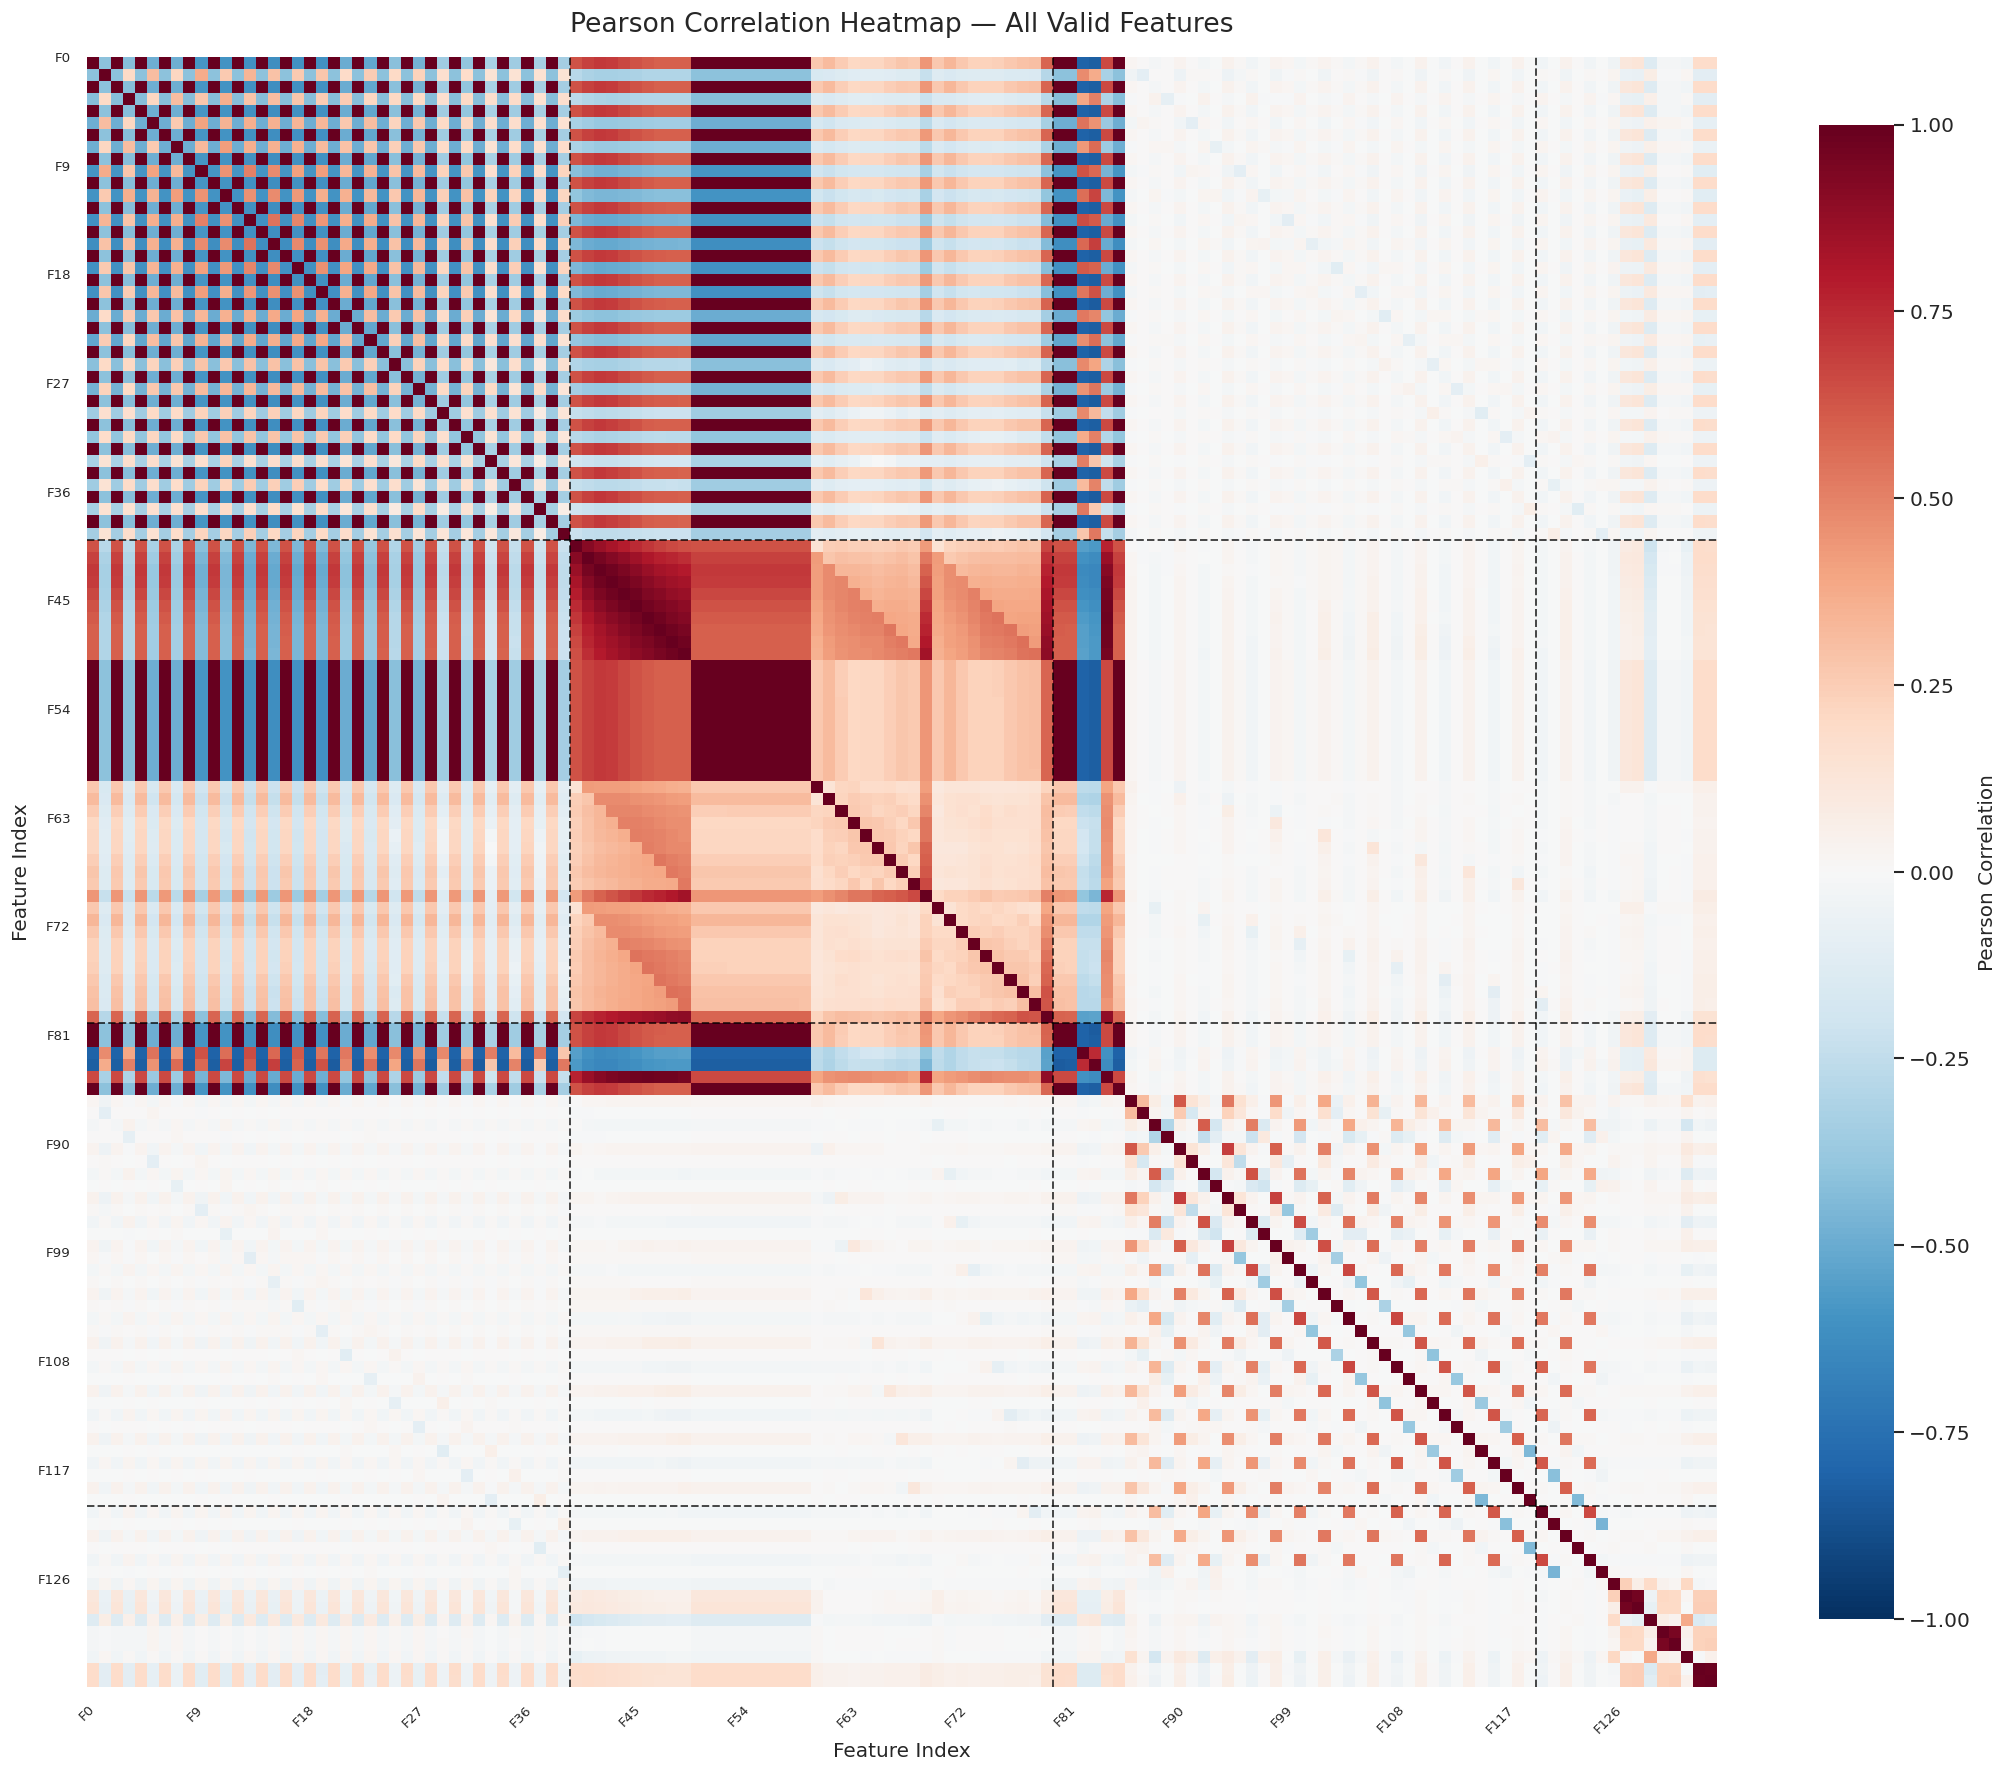


Block boundaries at features 40, 80, 120 correspond to the four
groups of LOB depth levels in the FI-2010 feature layout.


In [13]:
# ── Correlation heatmap (seaborn) ───────────────────────────────────────────
# Uses only the valid (non-constant) features to avoid NaN artefacts.

fig, ax = plt.subplots(figsize=(18, 16))

# Build readable tick labels from valid feature indices
tick_step = max(1, n_valid // 15)  # ~15 ticks for readability
tick_positions = list(range(0, n_valid, tick_step))
tick_labels = [f"F{valid_indices[i]}" for i in tick_positions]

sns.heatmap(
    corr_matrix,
    cmap="RdBu_r",
    vmin=-1, vmax=1,
    center=0,
    square=True,
    xticklabels=False,
    yticklabels=False,
    cbar_kws={"label": "Pearson Correlation", "shrink": 0.8},
    ax=ax,
    linewidths=0,
)

# Add manual tick labels
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, fontsize=8, rotation=45)
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels, fontsize=8)

# Mark the 40-feature group boundaries (mapped to valid-feature space)
for boundary in [40, 80, 120]:
    # Find position in the valid array closest to this boundary
    pos = np.searchsorted(valid_indices, boundary)
    if pos < n_valid:
        ax.axhline(pos, color="black", linewidth=1.2, linestyle="--", alpha=0.7)
        ax.axvline(pos, color="black", linewidth=1.2, linestyle="--", alpha=0.7)

ax.set_title("Pearson Correlation Heatmap — All Valid Features", fontsize=16, pad=15)
ax.set_xlabel("Feature Index", fontsize=12)
ax.set_ylabel("Feature Index", fontsize=12)

plt.tight_layout()
plt.show()

print("\nBlock boundaries at features 40, 80, 120 correspond to the four")
print("groups of LOB depth levels in the FI-2010 feature layout.")

---
## Summary

| Aspect | Observation |
|:---|:---|
| **Shape** | 9 anchored folds, 144 features per sample, 3 target classes |
| **Data types** | float32 (features), int64 (labels) |
| **Missing values** | None — dataset is fully pre-processed |
| **Feature scale** | Z-score normalised — centred near 0 with std ≈ 1 |
| **Skewness** | Several features show notable skew (especially volume-related) |
| **Kurtosis** | Heavy-tailed distributions present, indicating outlier-prone features |
| **Correlations** | Strong block-diagonal structure reflecting LOB depth levels & time horizons |